**Практическая работа №10**. Линейная регрессия и прогнозирование тормозного пути

**Задача**: прогнозирование тормозного пути на основе текущей скорости

**Алгоритм Работы**:
1. С помощью `pandas.read_csv` загружается файл `"./Data/mycar_lin.csv"`.
2. С помощью `train_test_split` из `sklearn.model_selection` делятся данные: 80% обучение, 20% тест.
3. Сохраняется `X_train, X_test, y_train, y_test` в виде `Xtr, Xte, Ytr, Yte`.
3. Используется `LinearRegression` из `sklearn.linear_model` для обучения модели на основе данных: `Xtr, Ytr`.
4. Прогнозирование на тестовых данных
5. С помощью `model.predict(X_test)` получается предсказания `y_pred`.
6. Рассчитываются метрики:
    6.1. MAE (средняя абсолютная ошибка)
    6.2. RMSE (корень из средней квадратичной ошибки)
    6.3. R² (коэффициент детерминации)
    6.4. Угловой коэффициент (coef_) и смещение (intercept_) модели.
7. Возможность прогноза нового значения



In [ ]:
#т.к. тут тема немонго нестандартная для моего понимания(здешняя структура модели не походит на структуру KAN, с которой я работаю) 
#     Буду разжевывать всё детально

# В данном задании требуется написать модель предсказания, это больше по части нейронок, а так как я не хочу писать все нужные функции, то
#     Применяю стандартизированный для этого sklearn метод
import sklearn.model_selection  as m1
import sklearn.linear_model as m2
import sklearn.metrics as m3
#Это уже стандартные библиотеки:
import pandas  as pd
import numpy as np
#Контсанты, их не учитываю, ибо это материал предыдущих лаб(на всякий, 
#                      тут те же привычные модельщикам x_train и y_train это SPEED и STDIST соотвественно)
DATASET = pd.read_csv("./Data/mycar_lin.csv")
SPEED = DATASET[["Speed"]]
STDIST = DATASET[["Stopping_dist"]]

# Здесь приводиться весь датасет к нужному виду для создание модели
Xtr, Xte, Ytr, Yte = m1.train_test_split(SPEED, STDIST, test_size=0.2, random_state=42)

#Создание и обучения самой модели лоинейной регрессии
model = m2.LinearRegression()
model.fit(Xtr, Ytr)

#Ряд предсказаний для метрик

Yp = model.predict(Xte)
#тут уже метрики, конечно же, можно было нормально сделать их так, чтобы они ещё и в отдельних переменных были, но  всё будет в принте
print(f"""
Главные метрические коэфиценты:
 Угол наклона: {model.coef_[0][0]}
 Смещение:     {model.intercept_}
 MAE:          {m3.mean_absolute_error(Yte, Yp)}
 RMSE:         {np.sqrt(m3.mean_squared_error(Yte, Yp))}
 R^2:          {m3.r2_score(Yte, Yp)}
 
""")


# Ну а тут уже возможность поиграться с прогнозами этой модельки. ВНИМАНИЕ! МОГУТ БЫТЬ ОШИБКИ ИЗ-ЗА ТОГО, ЧТО МОДЕЛЬ СТРОИЛ РУКОЖОП
while True:
    try:
        data = float(input("Значение(КМ\Ч):"))
        print(f"Тормозной путь: {model.predict(np.array([[data]]))}")
    except Exceptions:
        data = float(input("Значение(КМ\Ч):"))
        print(f"Тормозной путь: {model.predict(np.array([[data]]))}")

**Ответы на вопросы**:
1. Моделирование проведения данных. Прогнозирование
Идея: используем имеющиеся данные, чтобы предсказать значения новой переменной.
Пример: у нас есть скорость автомобиля (Speed) и тормозной путь (Stopping_dist). Мы хотим, зная скорость, предсказать тормозной путь.

2. Линейная регрессия

Простая линейная регрессия: один признак, одна зависимая переменная.
𝑦 =𝑏_0+𝑏_1𝑥

где 𝑏_1 — угловой коэффициент, 
𝑏_0 — смещение.

Множественная линейная регрессия: несколько признаков.

𝑦=𝑏_0+𝑏_1𝑥_1+𝑏_2𝑥_2+...+𝑏_𝑛𝑥_𝑛
3. Разбиение данных на тестовые и обучающие

Синтаксис Python:
```
from sklearn.model_selection import train_test_split
Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.2, random_state=42)
```

80% данных идет на обучение (Xtr, Ytr), 20% на тест (Xte, Yte).

4. Функция map()

Синтаксис: применяется к итерируемым объектам для преобразования элементов.
```
nums = [1, 2, 3, 4]
squared = list(map(lambda x: x**2, nums))
# результат: [1, 4, 9, 16]
```
5. Оценка качества модели — Метрики

MAE (Mean Absolute Error) — средняя абсолютная ошибка:
```
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Yte, Yp)
```

Пример: если предсказали `[10, 15, 20]`, а реально `[12, 14, 18]`, `MAE = (|10-12| + |15-14| + |20-18|)/3 = 1.666`

RMSE (Root Mean Squared Error) — корень из средней квадратичной ошибки:
```
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(Yte, Yp))
```

Коэффициент детерминации R² — насколько модель объясняет дисперсию данных:
```
from sklearn.metrics import r2_score
r2 = r2_score(Yte, Yp)
```
6. Анализ выбросов в `mycar_lin.csv`


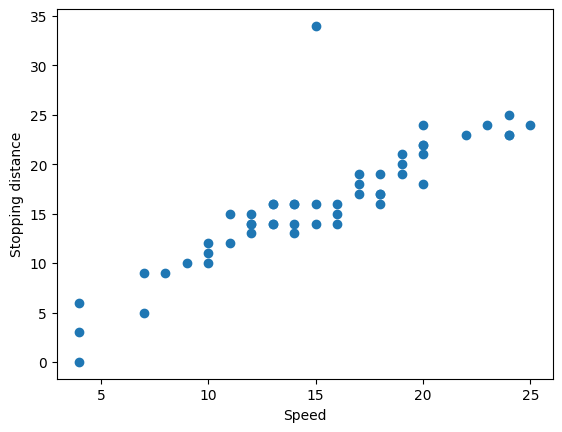

In [25]:
import matplotlib.pyplot as plt
plt.scatter(DATASET['Speed'], DATASET['Stopping_dist'])
plt.xlabel('Speed')
plt.ylabel('Stopping distance')
plt.show()


7. Построение модели прогнозирования

Алгоритм:

7.1. Загружаем данные (`Speed, Stopping_dist`)

7.2. Делим на `Xtr, Xte, Ytr, Yte`

7.3. Создаем `LinearRegression()`

7.3. Обучаем модель `model.fit(Xtr, Ytr)`

7.4. Делаем предсказания `Yp = model.predict(Xte)`

7.5. Считаем метрики `MAE, RMSE, R²`


7.6. Угловой коэффициент (c`oef_`) — показывает, как меняется тормозной путь с изменением скорости.

7.7. Смещение (`intercept_`) — тормозной путь при нулевой скорости (теоретически).

7.8. Метрики: `MAE, RMSE и R²` показывают точность предсказаний.